In [1]:
#CELL 1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# CELL 2 — Install Dependencies
!pip install -q "qwen-vl-utils" "accelerate>=0.26.0"
!pip install -q git+https://github.com/huggingface/transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 34.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
# CELL 3 — Imports & Paths
import os, json, time, gc, re
from pathlib import Path
from datetime import datetime
import torch
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
from qwen_vl_utils import process_vision_info

BASE_DIR         = Path("/content/drive/MyDrive/Airplane_Detection")
IMAGES_DIR       = BASE_DIR / "images" / "test"
ANNOTATIONS_FILE = BASE_DIR / "annotations" / "test_annotations.coco.json"
PREDICTIONS_DIR  = BASE_DIR / "predictions"
PREDICTIONS_FILE = PREDICTIONS_DIR / "qwen3_predictions.json"
MODEL_NAME       = "Qwen/Qwen3-VL-4B-Instruct"
MAX_NEW_TOKENS   = 128

PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
assert IMAGES_DIR.exists(),       f"Missing: {IMAGES_DIR}"
assert ANNOTATIONS_FILE.exists(), f"Missing: {ANNOTATIONS_FILE}"
print("✅ Paths OK")

✅ Paths OK


In [4]:
# CELL 4 — Load COCO Annotations & Build Ground Truth (ALL annotations per image)
with open(ANNOTATIONS_FILE) as f:
    coco = json.load(f)

id_to_filename = {img["id"]: img["file_name"] for img in coco["images"]}
categories     = {cat["id"]: cat["name"] for cat in coco["categories"]}

# Initialize all images
ground_truth = {
    fname: {"airplane_present": False, "bboxes": [], "count": 0}
    for fname in id_to_filename.values()
}

# Load ALL annotations — not just first one per image
for ann in coco.get("annotations", []):
    fname = id_to_filename.get(ann["image_id"])
    if fname and isinstance(ann.get("bbox"), list) and len(ann["bbox"]) == 4:
        ground_truth[fname]["airplane_present"] = True
        ground_truth[fname]["bboxes"].append(ann["bbox"])

# Set count from actual bbox list length
for fname in ground_truth:
    ground_truth[fname]["count"] = len(ground_truth[fname]["bboxes"])

pos     = sum(1 for v in ground_truth.values() if v["airplane_present"])
neg     = len(ground_truth) - pos
total_a = sum(v["count"] for v in ground_truth.values())

print(f"Images           : {len(coco['images'])}")
print(f"Annotations      : {len(coco['annotations'])}")
print(f"Categories       : {categories}")
print(f"Positive images  : {pos}")
print(f"Negative images  : {neg}")
print(f"Total GT boxes   : {total_a}")
print(f"Avg boxes/image  : {total_a/max(pos,1):.1f}")
print("✅ Ground truth loaded with ALL annotations")

Images           : 34
Annotations      : 497
Categories       : {0: 'planes', 1: 'airplane'}
Positive images  : 34
Negative images  : 0
Total GT boxes   : 497
Avg boxes/image  : 14.6
✅ Ground truth loaded with ALL annotations


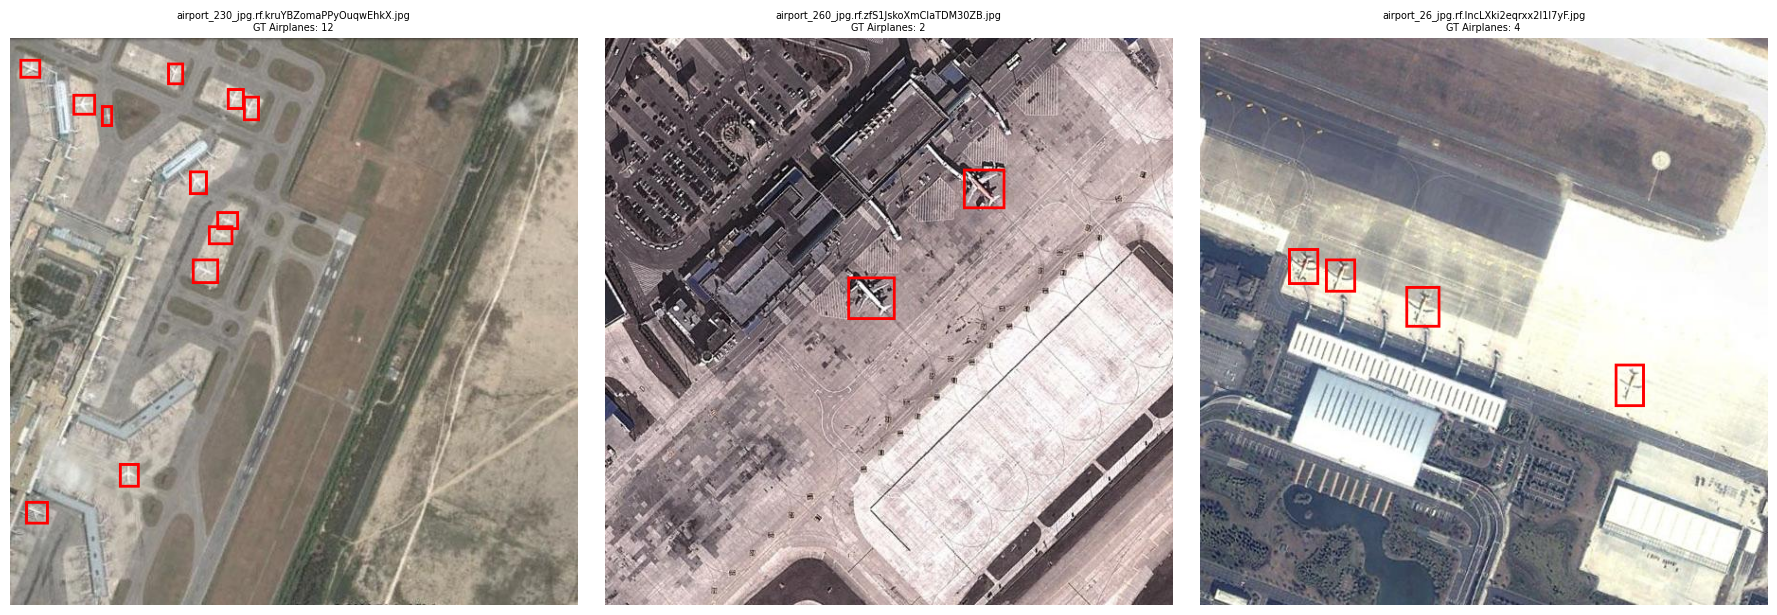

In [5]:
# CELL 5 — Visualize 3 Sample Images with ALL Ground Truth Bounding Boxes
samples = [k for k, v in ground_truth.items() if v["airplane_present"]][:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, fname in zip(axes, samples):
    img  = Image.open(IMAGES_DIR / fname).convert("RGB")
    draw = ImageDraw.Draw(img)
    for bbox in ground_truth[fname]["bboxes"]:
        x, y, w, h = bbox
        draw.rectangle([x, y, x+w, y+h], outline="red", width=3)
    count = ground_truth[fname]["count"]
    ax.imshow(img)
    ax.set_title(f"{fname}\nGT Airplanes: {count}", fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# CELL 6 — Load Model
print(f"Loading {MODEL_NAME} ...")
model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()
processor = AutoProcessor.from_pretrained(MODEL_NAME)
print(f"✅ Model loaded | VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading Qwen/Qwen3-VL-4B-Instruct ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/64.7k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

✅ Model loaded | VRAM used: 8.88 GB


In [18]:
# TEMP DEBUG — See exact raw output from model for bbox request
from PIL import Image
from qwen_vl_utils import process_vision_info
import torch, re

GROUNDING_PROMPT = (
    "Look at this aerial airport image.\n"
    "List the bounding box of every airplane you see.\n"
    "Format: {\"bboxes\": [[x1,y1,x2,y2], [x1,y1,x2,y2]], \"predicted_count\": integer}\n"
    "Use pixel coordinates. x1,y1=top-left. x2,y2=bottom-right. JSON only."
)

test_fname = [k for k,v in ground_truth.items() if v["airplane_present"]][0]
test_path  = Path(IMAGES_DIR) / test_fname
image      = Image.open(test_path).convert("RGB")
print(f"Image: {test_fname}  Size: {image.size}")

messages = [{"role": "user", "content": [
    {"type": "image", "image": image},
    {"type": "text",  "text": GROUNDING_PROMPT}
]}]
text_input   = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text_input], images=image_inputs, videos=video_inputs,
                   padding=True, return_tensors="pt").to(model.device)
with torch.no_grad():
    gen_ids = model.generate(**inputs, max_new_tokens=512, do_sample=False,
                             temperature=None, top_p=None,
                             pad_token_id=processor.tokenizer.eos_token_id)
trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, gen_ids)]
raw = processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()

print("="*60)
print("FULL RAW OUTPUT:")
print(raw)
print("="*60)
print("REPR:")
print(repr(raw))

Image: airport_230_jpg.rf.kruYBZomaPPyOuqwEhkX.jpg  Size: (600, 600)
FULL RAW OUTPUT:
{"bboxes": [], "predicted_count": 0}
REPR:
'{"bboxes": [], "predicted_count": 0}'


In [7]:
# CELL 7 — Inference Function & Parser
PROMPT = (
    "Look at this aerial satellite image of an airport.\n"
    "Are there any airplanes visible?\n"
    "How many airplanes can you count?\n\n"
    "Respond with ONLY this JSON on a single line. No newlines inside JSON. No markdown. No explanation:\n"
    '{"airplane_present": true or false, "predicted_count": integer, "confidence": 0.0-1.0}'
)

def run_inference(image_path):
    image = Image.open(image_path).convert("RGB")
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text": PROMPT}
    ]}]
    text_input = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text_input], images=image_inputs, videos=video_inputs,
        padding=True, return_tensors="pt"
    ).to(model.device)
    with torch.no_grad():
        gen_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=processor.tokenizer.eos_token_id
        )
    trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, gen_ids)]
    return processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()

def parse_prediction(raw):
    if not raw or not raw.strip():
        return None
    try:
        # Remove markdown fences
        cleaned = re.sub(r"```[\w]*", "", raw).replace("```", "").strip()

        # Collapse all whitespace/newlines inside JSON to single spaces
        cleaned = re.sub(r"\s+", " ", cleaned)

        # Find outermost { }
        start = cleaned.find("{")
        end   = cleaned.rfind("}")

        # Try to repair missing closing brace
        if start != -1 and end == -1:
            cleaned = cleaned.rstrip().rstrip(",") + " }"
            end = cleaned.rfind("}")

        if start == -1 or end == -1 or end <= start:
            return None

        json_str = cleaned[start:end+1]

        # Remove trailing commas before } or ]
        json_str = re.sub(r",\s*([}\]])", r"\1", json_str)

        p = json.loads(json_str)

        airplane = p.get("airplane_present", False)
        if isinstance(airplane, str):
            airplane = airplane.lower() == "true"

        conf = p.get("confidence", 0.0)
        try:
            conf = max(0.0, min(1.0, float(conf)))
        except (TypeError, ValueError):
            conf = 0.0

        count = p.get("predicted_count", 0)
        try:
            count = int(count)
        except (TypeError, ValueError):
            count = 0

        return {
            "airplane_present": bool(airplane),
            "predicted_count":  count,
            "bboxes":           [],
            "confidence":       round(conf, 4),
        }
    except Exception:
        return None

In [8]:
# CELL 8 — Run Batch Inference
available   = {f.name for f in IMAGES_DIR.iterdir() if f.suffix.lower() in {".jpg", ".jpeg", ".png"}}
image_names = sorted(available & set(ground_truth.keys()))
total       = len(image_names)
print(f"Processing {total} images...\n")

predictions, failed = {}, {}
start = time.time()

for idx, name in enumerate(image_names, 1):
    try:
        raw  = run_inference(IMAGES_DIR / name)
        pred = parse_prediction(raw)
        if pred is None:
            raise ValueError(f"Unparseable: {repr(raw)}")
        predictions[name] = pred
        print(f"✅ Processed {idx}/{total} | {name} | airplane={pred['airplane_present']} | count={pred['predicted_count']} | conf={pred['confidence']:.2f}")
    except Exception as e:
        failed[name] = str(e)
        print(f"❌ Failed    {idx}/{total} | {name} | {str(e)[:80]}")
    finally:
        gc.collect()
        torch.cuda.empty_cache()

elapsed = time.time() - start
print(f"\nDone in {elapsed:.1f}s | {elapsed/max(total,1):.2f}s/image")

Processing 34 images...

✅ Processed 1/34 | airport_100_jpg.rf.SgVI5S0YAGG0OACKq5Lb.jpg | airplane=True | count=12 | conf=0.85
✅ Processed 2/34 | airport_104_jpg.rf.1pOVstMo6rclUbOXLaSs.jpg | airplane=True | count=12 | conf=0.85
✅ Processed 3/34 | airport_110_jpg.rf.wXyE2INx62V87ES0BByM.jpg | airplane=True | count=14 | conf=0.85
✅ Processed 4/34 | airport_118_jpg.rf.dnpyW1NCEmxTzG9jFxyE.jpg | airplane=True | count=20 | conf=0.95
✅ Processed 5/34 | airport_132_jpg.rf.SIPv0mdsmn2vWOaiVVNq.jpg | airplane=False | count=0 | conf=0.98
✅ Processed 6/34 | airport_133_jpg.rf.0E3hNlE6NgJuarLbWrpq.jpg | airplane=True | count=4 | conf=0.85
✅ Processed 7/34 | airport_164_jpg.rf.TzcDiRMAsVDOd7VshVuq.jpg | airplane=True | count=4 | conf=0.85
✅ Processed 8/34 | airport_197_jpg.rf.mJn5ogY25an7yaWLqKYA.jpg | airplane=True | count=10 | conf=0.85
✅ Processed 9/34 | airport_207_jpg.rf.o6l0TBZ3fIUNMkzJfxQ1.jpg | airplane=True | count=12 | conf=0.85
✅ Processed 10/34 | airport_20_jpg.rf.FHDweD24NzVCj83UBwHv.

In [9]:
# CELL 9 — Save Predictions
output = {
    "_metadata": {
        "model":            MODEL_NAME,
        "generated_at":     datetime.now().isoformat() + "Z",
        "total_images":     total,
        "successful":       len(predictions),
        "failed":           len(failed),
        "elapsed_seconds":  round(elapsed, 2),
        "max_new_tokens":   MAX_NEW_TOKENS,
    },
    "predictions": predictions,
    "failed":      failed,
}
with open(PREDICTIONS_FILE, "w") as f:
    json.dump(output, f, indent=2)
print(f"✅ Saved to {PREDICTIONS_FILE}  ({PREDICTIONS_FILE.stat().st_size/1024:.1f} KB)")

✅ Saved to /content/drive/MyDrive/Airplane_Detection/predictions/qwen3_predictions.json  (5.8 KB)


In [22]:
# CELL 9D — Train YOLOv8 on YOUR dataset then visualize

!pip install -q ultralytics

# ── Step 1: Convert your COCO annotations to YOLO format ──────────────
import json, os, shutil
from pathlib import Path
from PIL import Image

YOLO_DIR    = Path("/content/yolo_dataset")
IMG_OUT     = YOLO_DIR / "images" / "train"
LBL_OUT     = YOLO_DIR / "labels" / "train"
IMG_OUT.mkdir(parents=True, exist_ok=True)
LBL_OUT.mkdir(parents=True, exist_ok=True)

with open(ANNOTATIONS_FILE) as f:
    coco = json.load(f)

id_to_fname  = {img["id"]: img["file_name"] for img in coco["images"]}
id_to_size   = {img["id"]: (img["width"], img["height"]) for img in coco["images"]}
img_anns     = {}
for ann in coco["annotations"]:
    img_anns.setdefault(ann["image_id"], []).append(ann["bbox"])

for img_id, fname in id_to_fname.items():
    src = Path(IMAGES_DIR) / fname
    if not src.exists():
        continue
    shutil.copy(src, IMG_OUT / fname)

    w, h   = id_to_size[img_id]
    bboxes = img_anns.get(img_id, [])
    label_path = LBL_OUT / (Path(fname).stem + ".txt")
    with open(label_path, "w") as f:
        for bbox in bboxes:
            x, y, bw, bh = bbox
            xc = (x + bw/2) / w
            yc = (y + bh/2) / h
            nw = bw / w
            nh = bh / h
            f.write(f"0 {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}\n")

# ── Step 2: Write dataset.yaml ────────────────────────────────────────
yaml_content = f"""
path: {YOLO_DIR}
train: images/train
val:   images/train

nc: 1
names: ['airplane']
"""
with open(YOLO_DIR / "dataset.yaml", "w") as f:
    f.write(yaml_content)

print("✅ Dataset ready")
print(f"   Images : {len(list(IMG_OUT.iterdir()))}")
print(f"   Labels : {len(list(LBL_OUT.iterdir()))}")

✅ Dataset ready
   Images : 34
   Labels : 34


In [23]:
# ── Step 3: Train YOLOv8 on your airplane data ────────────────────────
from ultralytics import YOLO

yolo = YOLO("yolov8n.pt")
yolo.train(
    data=str(YOLO_DIR / "dataset.yaml"),
    epochs=30,
    imgsz=640,
    batch=8,
    name="airplane_detector",
    verbose=False
)
print("✅ Training complete")

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=airplane_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

In [24]:
# ── Step 4: Visualize GT vs Trained YOLO predictions ──────────────────
import cv2, random
from ultralytics import YOLO
from matplotlib.patches import Patch

best_weights = Path("runs/detect/airplane_detector/weights/best.pt")
yolo_trained = YOLO(str(best_weights))

def get_trained_boxes(image_path, conf=0.25):
    results = yolo_trained(str(image_path), verbose=False, conf=conf)
    boxes   = []
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            boxes.append([int(x1), int(y1), int(x2-x1), int(y2-y1)])
    return boxes

candidates = [k for k,v in ground_truth.items()
              if v["airplane_present"] and (Path(IMAGES_DIR)/k).exists()]
sample     = random.sample(candidates, min(5, len(candidates)))

fig, axes  = plt.subplots(1, len(sample), figsize=(6*len(sample), 7))
if len(sample) == 1:
    axes = [axes]

for ax, fname in zip(axes, sample):
    img_path = Path(IMAGES_DIR) / fname
    img      = cv2.imread(str(img_path))
    img      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    overlay  = img.copy()

    # GT boxes — Green
    gt_count = ground_truth[fname].get("count", 0)
    for bbox in ground_truth[fname].get("bboxes", []):
        if len(bbox) == 4:
            x, y, bw, bh = [int(v) for v in bbox]
            cv2.rectangle(overlay, (x, y), (x+bw, y+bh), (0, 200, 0), 2)
            cv2.putText(overlay, "GT", (x, max(y-4, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 200, 0), 2)

    # Trained YOLO boxes — Red
    pred_boxes = get_trained_boxes(img_path)
    pred_count = len(pred_boxes)
    for bbox in pred_boxes:
        x, y, bw, bh = bbox
        cv2.rectangle(overlay, (x, y), (x+bw, y+bh), (220, 30, 30), 2)
        cv2.putText(overlay, "P", (x, max(y-4, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (220, 30, 30), 2)

    ax.imshow(overlay)
    ax.set_title(f"{fname[:25]}\nGT:{gt_count}  Pred:{pred_count}", fontsize=7)
    ax.axis("off")

fig.legend(handles=[
    Patch(facecolor=(0, 200/255, 0),             label="Ground Truth"),
    Patch(facecolor=(220/255, 30/255, 30/255),   label="YOLO Trained Predicted"),
], loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04))
plt.suptitle("GT Boxes (Green) vs Trained YOLO Boxes (Red)", fontsize=12)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

/tmp/ipykernel_627/1823914168.py:52: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


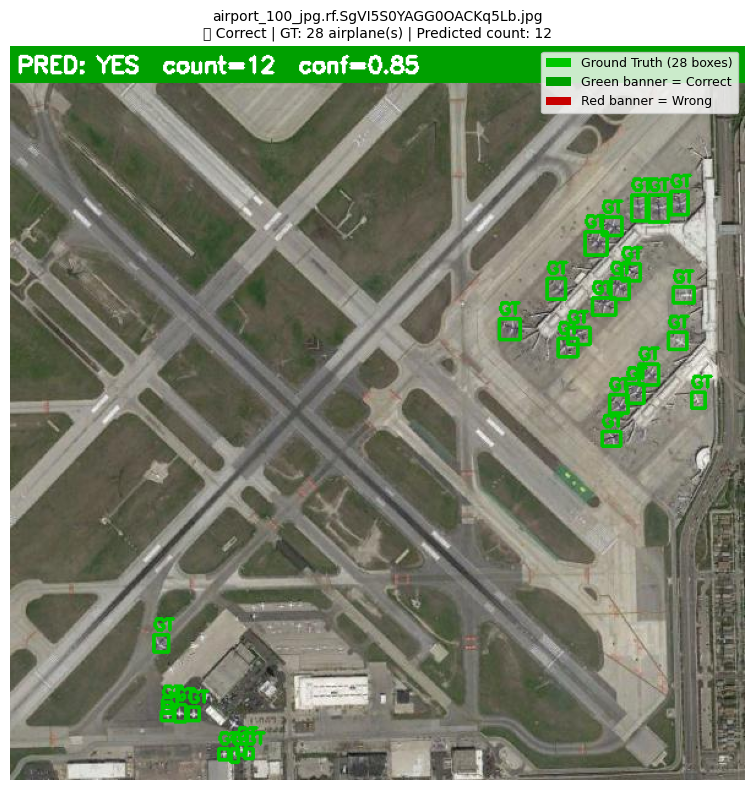

In [13]:
#CELL 9B
def visualize_single(fname, ground_truth, predictions, images_dir):
    img_path = Path(images_dir) / fname
    if not img_path.exists():
        print(f"Image not found: {fname}")
        return

    img     = cv2.imread(str(img_path))
    img     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    overlay = img.copy()

    gt        = ground_truth.get(fname, {})
    gt_bboxes = gt.get("bboxes", [])
    gt_count  = gt.get("count", 0)
    for bbox in gt_bboxes:
        if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
            try:
                x, y, bw, bh = [int(v) for v in bbox]
                cv2.rectangle(overlay, (x, y), (x+bw, y+bh), (0, 200, 0), 2)
                cv2.putText(overlay, "GT", (x, max(y-4, 12)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 200, 0), 2)
            except (TypeError, ValueError):
                pass

    pred       = predictions.get(fname, {})
    pred_label = pred.get("airplane_present", False) if pred else False
    pred_count = pred.get("predicted_count", 0)      if pred else 0
    conf       = pred.get("confidence", 0.0)         if pred else 0.0
    gt_label   = gt.get("airplane_present", False)
    correct    = pred_label == gt_label

    banner_color = (0, 160, 0) if correct else (200, 0, 0)
    banner_text  = f"PRED: {'YES' if pred_label else 'NO'}  count={pred_count}  conf={conf:.2f}"
    cv2.rectangle(overlay, (0, 0), (overlay.shape[1], 30), banner_color, -1)
    cv2.putText(overlay, banner_text, (6, 22),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(overlay)
    status = "✅ Correct" if correct else "❌ Wrong"
    ax.set_title(
        f"{fname}\n{status} | GT: {gt_count} airplane(s) | Predicted count: {pred_count}",
        fontsize=10
    )
    ax.axis("off")
    legend = [
        Patch(facecolor=(0, 200/255, 0),   label=f"Ground Truth ({gt_count} boxes)"),
        Patch(facecolor=(0, 160/255, 0),   label="Green banner = Correct"),
        Patch(facecolor=(200/255, 0, 0),   label="Red banner = Wrong"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()

sample_name = next(iter(predictions), None)
if sample_name:
    visualize_single(sample_name, ground_truth, predictions, IMAGES_DIR)
else:
    print("No predictions available.")

In [16]:
#CELL 9C
def visualize_batch(ground_truth, predictions, images_dir, n=5):
    candidates = [name for name in ground_truth
                  if (Path(images_dir) / name).exists()]
    if not candidates:
        print("No valid images found.")
        return

    sample = random.sample(candidates, min(n, len(candidates)))
    fig, axes = plt.subplots(1, len(sample), figsize=(5*len(sample), 6))
    if len(sample) == 1:
        axes = [axes]

    for ax, fname in zip(axes, sample):
        img = cv2.imread(str(Path(images_dir) / fname))
        if img is None:
            ax.axis("off")
            continue
        img     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        overlay = img.copy()

        gt        = ground_truth.get(fname, {})
        gt_bboxes = gt.get("bboxes", [])
        gt_count  = gt.get("count", 0)
        for bbox in gt_bboxes:
            if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
                try:
                    x, y, bw, bh = [int(v) for v in bbox]
                    cv2.rectangle(overlay, (x, y), (x+bw, y+bh), (0, 200, 0), 2)
                except (TypeError, ValueError):
                    pass

        pred       = predictions.get(fname)
        pred_label = pred.get("airplane_present", False) if pred else False
        pred_count = pred.get("predicted_count", 0)      if pred else 0
        conf       = pred.get("confidence", 0.0)         if pred else 0.0
        gt_label   = gt.get("airplane_present", False)
        correct    = pred_label == gt_label

        banner_color = (0, 160, 0) if correct else (200, 0, 0)
        banner_text  = f"{'YES' if pred_label else 'NO'} cnt={pred_count} c={conf:.2f}"
        cv2.rectangle(overlay, (0, 0), (overlay.shape[1], 28), banner_color, -1)
        cv2.putText(overlay, banner_text, (4, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)

        status = "✅" if correct else "❌"
        ax.imshow(overlay)
        ax.set_title(f"{status} {fname[:25]}\nGT:{gt_count} Pred:{pred_count}",
                     fontsize=7)
        ax.axis("off")

    fig.legend(handles=[
        Patch(facecolor=(0, 200/255, 0), label="Ground Truth boxes"),
        Patch(facecolor=(0, 160/255, 0), label="Green banner = Correct"),
        Patch(facecolor=(200/255, 0, 0), label="Red banner = Wrong"),
    ], loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.06))
    plt.suptitle("Ground Truth Boxes (Green) + Classification Banner",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

visualize_batch(ground_truth, predictions, IMAGES_DIR, n=5)

Output hidden; open in https://colab.research.google.com to view.

In [17]:
TP = TN = FP = FN = 0
confs = []

for name, pred in predictions.items():
    gt_label = ground_truth.get(name, {}).get("airplane_present", False)
    p_label  = pred.get("airplane_present", False)
    if   gt_label and p_label:         TP += 1
    elif not gt_label and not p_label: TN += 1
    elif not gt_label and p_label:     FP += 1
    else:                              FN += 1
    confs.append(pred.get("confidence", 0.0))

n         = TP + TN + FP + FN
accuracy  = (TP + TN) / n             if n               else 0
precision = TP / (TP + FP)            if (TP + FP)       else 0
recall    = TP / (TP + FN)            if (TP + FN)       else 0
f1        = 2*precision*recall / (precision + recall) if (precision + recall) else 0
mean_conf = sum(confs) / len(confs)   if confs           else 0
mins, secs = divmod(int(elapsed), 60)

print("═"*50)
print("   QWEN3-VL-4B AIRPLANE DETECTION — SUMMARY")
print("═"*50)
print(f"  Model              : {MODEL_NAME}")
print(f"  Total Images       : {total}")
print(f"  Successful Preds   : {len(predictions)}")
print(f"  Failed             : {len(failed)}")
print(f"  Execution Time     : {mins}m {secs}s")
print("─"*50)
print(f"  Accuracy           : {accuracy*100:.1f}%")
print(f"  Precision          : {precision:.4f}")
print(f"  Recall             : {recall:.4f}")
print(f"  F1 Score           : {f1:.4f}")
print(f"  Mean Confidence    : {mean_conf:.4f}")
print("─"*50)
print(f"  TP={TP}  TN={TN}  FP={FP}  FN={FN}")
print("═"*50)

══════════════════════════════════════════════════
   QWEN3-VL-4B AIRPLANE DETECTION — SUMMARY
══════════════════════════════════════════════════
  Model              : Qwen/Qwen3-VL-4B-Instruct
  Total Images       : 34
  Successful Preds   : 34
  Failed             : 0
  Execution Time     : 1m 55s
──────────────────────────────────────────────────
  Accuracy           : 97.1%
  Precision          : 1.0000
  Recall             : 0.9706
  F1 Score           : 0.9851
  Mean Confidence    : 0.8950
──────────────────────────────────────────────────
  TP=33  TN=0  FP=0  FN=1
══════════════════════════════════════════════════
